# 5. Other stuff
Aquí voy a poner básicamente el resto de cosas que vaya necesitando explorar.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
PATH_DATA = '../data'

### Preguntas para la introducción
- ¿Cuántos incidentes viales hay en promedio cada año en la CDMX?
- ¿Cuántas víctimas fatales hay? ¿Cuántos lesionados hay?
- ¿Cómo ha cambiado el número de accidentes a lo largo del tiempo, especialmente previo a la implementación del sistema de fotocívicas?

In [11]:
def assign_incident_level(row) -> str:
    """
    Assign the level of the incident based on the following rules:

    MIN - Aquellos incidentes menores en los que no haya lesionados o fatalidades
    PIC - Incidentes con lesiones personales para algún involucrado
    FCS - Incidentes fatales donde la vida de una o más personas se haya perdido
    """
    tipo_incidente = row["tipo_incidente_c4"]
    if tipo_incidente in ["Cadáver"]:
        return "FCS"

    # Para este punto ya nada más quedan Accidentes y lesionados
    emergency_level = row["clas_con_f_alarma"]
    if emergency_level == "URGENCIAS MEDICAS": # Todos los lesionados están aquí
        return "PIC"
    return "MIN" # Aquí solo quedan accidentes menores

In [92]:
INCIDENT_TYPE = ["Accidente", "Cadáver", "Lesionado"]
INICIO_OPERACIONES = pd.to_datetime("2019-04-22")

accidentes = (
    pd
    .read_parquet(os.path.join(PATH_DATA, 'incidentes-viales.parquet'))
    .reset_index(drop=True)
    .pipe(
        lambda df: 
        gpd
        .GeoDataFrame(
            data=df.drop(['latitud', 'longitud'], axis=1),
            geometry=gpd.points_from_xy(df.longitud, df.latitud)
        )
    )
    # Eliminamos estas categorías: Detención ciudadana, Mi Calle, Mi Taxi, Sismo -> 432,707
    .query("tipo_incidente_c4 in @INCIDENT_TYPE and clas_con_f_alarma != 'FALSA ALARMA'")
    # Y ahora hay que clasificar cada uno de los incidentes
    # MIN    239069
    # PIC    191681
    # FCS      1957
    .assign(
        incident_level=lambda df: df.apply(assign_incident_level, axis=1),
        hour=lambda x: x.timestamp.dt.hour,
        weekday=lambda x: x.timestamp.dt.day_name(),
        before_treatment=lambda x: x.timestamp.apply(lambda t: t < INICIO_OPERACIONES)
    )
    .query("'2014-01-01' <= timestamp <= '2023-12-31'") # De 2024 tenemos hasta el 20 de febrero, así que mejor lo quito también 
)

In [260]:
# ¿Cuántos incidentes viales hay en promedio cada año en la CDMX?
# Estoy considerando una ventana de 10 años (14, 15, 16, 17, 18, 19, 20, 21, 22, 23)

total_years = accidentes.timestamp.dt.year.unique().size

yearly_average_accidents = (
    accidentes
    .folio
    .size / total_years
)

print(f"En CDMX, entre los años de 2014 y 2023, hubo en promedio {round(yearly_average_accidents)} accidentes cada año.")

En CDMX, entre los años de 2014 y 2023, hubo en promedio 85150 accidentes cada año.


In [261]:
yearly_average_injured = (
    accidentes
    .query("incident_level == 'PIC'")
    .shape[0] / total_years
)
print(f"En CDMX, entre los años de 2014 y 2023, hubo en promedio {round(yearly_average_injured)} lesionados cada año.")

En CDMX, entre los años de 2014 y 2023, hubo en promedio 37638 lesionados cada año.


In [262]:
# ¿Cuántos accidentes fatales hubo en promedio cada año?
yearly_average_deaths = (
    accidentes
    .query("incident_level == 'FCS'")
    .shape[0] / total_years
)

print(f"En CDMX, entre los años de 2014 y 2023, hubo en promedio {round(yearly_average_deaths)} muertes cada año, \
es decir, durante los {total_years} años que se estudian, hubo más de un muerto cada día, esto solo considerando las muertes en el sitio del accidente")

En CDMX, entre los años de 2014 y 2023, hubo en promedio 383 muertes cada año, es decir, durante los 10 años que se estudian, hubo más de un muerto cada día, esto solo considerando las muertes en el sitio del accidente


In [179]:
# ¿Cómo se ve la tendencia en el número de incidentes viales cada año?
pdf = (
    accidentes
    .groupby(pd.Grouper(key="timestamp", freq="1Y")) 
    .agg(
        incidentes=pd.NamedAgg("folio", "count"),
        menores=pd.NamedAgg("incident_level", lambda x: sum(x == "MIN")),
        lesionados=pd.NamedAgg("incident_level", lambda x: sum(x == "PIC")),
        fatales=pd.NamedAgg("incident_level", lambda x: sum(x == "FCS")),
    )
)

In [157]:
def add_column_as_text(df, column, ax, y_offset=0, **kwargs):
    """
    Annotate each point with the value in the given column,
    at coordinates (index, column value).
    """
    for i, val in zip(df.index, df[column]):
        ax.annotate(str(f"{val:,}"), xy=(i, val + y_offset), ha="center", va="bottom", **kwargs)

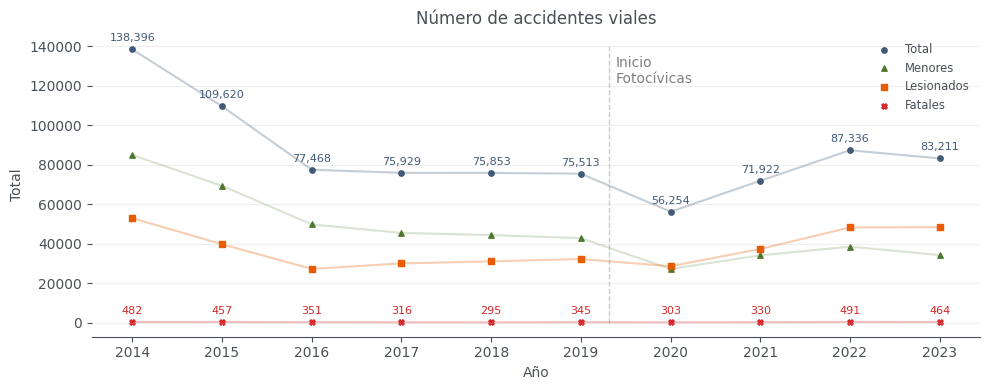

In [259]:
fig, ax = plt.subplots(1,1,figsize=(10,4))

ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(False)
ax.get_xaxis().set_ticks(
    ticks=pdf.index,
    labels=pdf.index.year
)

# Incidentes totales
color = "#415a77"
ax.plot(
    pdf.index, pdf.incidentes, color=color, linewidth=1.5, alpha=.3
)
ax.scatter(
    pdf.index, pdf.incidentes, color=color, marker='o', s=15, linewidth=1, label="Total"
)
add_column_as_text(
    df=pdf,
    column="incidentes", 
    ax=ax,
    y_offset=3_000,
    color=color,
    size=8
)

# Accidentes menores
color = "#4f772d"
column = "menores"
ax.plot(
    pdf.index, pdf[column], color=color, linewidth=1.5, alpha=.2
)
ax.scatter(
    pdf.index, pdf[column], color=color, marker="^", s=15, linewidth=1, label="Menores"
)

# Lesionados
color = "#e85d04"
column = "lesionados"
ax.plot(
    pdf.index, pdf[column], color=color, linewidth=1.5, alpha=.3
)
ax.scatter(
    pdf.index, pdf[column], color=color, marker='s', s=15, linewidth=1, label="Lesionados"
)

# Fatales
color = "#d62828"
column = "fatales"
ax.plot(
    pdf.index, pdf[column], color=color, linewidth=1.5, alpha=.3
)
ax.scatter(
    pdf.index, pdf[column], color=color, marker='X', s=15, linewidth=1, label="Fatales"
)
add_column_as_text(
    df=pdf,
    column=column, 
    ax=ax,
    y_offset=3_000,
    color=color,
    size=8
)

axis_color = "#495057"

ax.spines.bottom.set_color(axis_color)
ax.tick_params(axis='both', colors=axis_color)
ax.xaxis.label.set_color(axis_color)
ax.set_title("Número de accidentes viales", color=axis_color)
ax.set_ylabel("Total", color=axis_color)
ax.set_xlabel("Año", color=axis_color)

ax.vlines(
    x=pd.to_datetime("2020-04-22"), 
    ymin=0, ymax=140000, 
    zorder=-10, color="gray", 
    linestyles="dashed", 
    linewidth=1, alpha=.4
)

ax.annotate(
    "Inicio\nFotocívicas", 
    xy=(pd.to_datetime("2020-05-22"), 135000), 
    ha="left", 
    va="top", 
    color="gray"
)

ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False, ncols=1, fontsize="small", labelcolor=axis_color)
fig.tight_layout()
fig.savefig(os.path.join(PATH_DATA, "graphs", "yearly-number-of-incidents.png"), dpi=300, transparent=True)

plt.show()

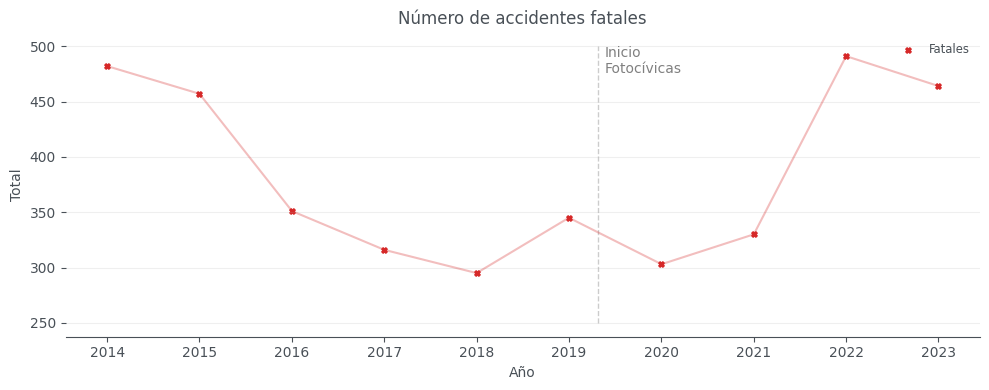

In [272]:
fig, ax = plt.subplots(1,1,figsize=(10,4))

ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(False)
ax.get_xaxis().set_ticks(
    ticks=pdf.index,
    labels=pdf.index.year
)

# Fatales
color = "#d62828"
column = "fatales"
ax.plot(
    pdf.index, pdf[column], color=color, linewidth=1.5, alpha=.3
)
ax.scatter(
    pdf.index, pdf[column], color=color, marker='X', s=15, linewidth=1, label="Fatales"
)
add_column_as_text(
    df=pdf,
    column=column, 
    ax=ax,
    y_offset=3_000,
    color=color,
    size=8
)

axis_color = "#495057"

ax.spines.bottom.set_color(axis_color)
ax.tick_params(axis='both', colors=axis_color)
ax.xaxis.label.set_color(axis_color)
ax.set_title("Número de accidentes fatales", color=axis_color)
ax.set_ylabel("Total", color=axis_color)
ax.set_xlabel("Año", color=axis_color)

ax.vlines(
    x=pd.to_datetime("2020-04-22"), 
    ymin=250, ymax=500, 
    zorder=-10, color="gray", 
    linestyles="dashed", 
    linewidth=1, alpha=.4
)

ax.annotate(
    "Inicio\nFotocívicas", 
    xy=(pd.to_datetime("2020-05-22"), 500), 
    ha="left", 
    va="top", 
    color="gray"
)

ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False, ncols=1, fontsize="small", labelcolor=axis_color)
fig.tight_layout()
fig.savefig(os.path.join(PATH_DATA, "graphs", "yearly-fatal-number-of-incidents.png"), dpi=300, transparent=True)
plt.show()

### Infracciones 

In [285]:
# Nota: estos datos están en un pdf, los hice a mano y los copié aquí para hacer la gráfica nada más
infracciones = pd.read_clipboard()

In [323]:
fig, ax = plt.subplots(1,1,figsize=(10,4))

ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(False)
ax.get_yaxis().set_ticks(
    ticks=range(0,4_000_001, 500_000),
    labels=["", "0.5M", "1M", "1.5M", "2M", "2.5M", "3M", "3.5M", "4M"]
)


ax.bar(infracciones.anio, infracciones.civica, color="#415a77", label="Cívicas")
ax.bar(infracciones.anio, infracciones.economica, color="#778da9", bottom=infracciones.civica, label="Económicas")

add_column_as_text(
    infracciones.set_index("anio").astype({"civica":int}),
    column="civica",
    ax=ax,
    y_offset=-205_000,
    color="white"
)

add_column_as_text(
    infracciones.set_index("anio").astype({"economica":int}),
    column="economica",
    ax=ax,
    y_offset=-100_000,
    color="white"
)

axis_color = "#495057"

ax.spines.bottom.set_color(axis_color)
ax.tick_params(axis='both', colors=axis_color)
ax.xaxis.label.set_color(axis_color)
ax.set_title("Número de infracciones por tipo de sanción", color=axis_color)
ax.set_ylabel("Total", color=axis_color)
ax.set_xlabel("Año", color=axis_color)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(PATH_DATA, "graphs", "yearly-number-of-sanctions.png"), dpi=300, transparent=True)
plt.close()

In [328]:
infracciones.assign(civica=lambda x: x.civica/(x.civica+x.economica)).civica.min()

0.14081482556665748